In [1]:
import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import langdetect
import emoji

In [2]:
df = pd.read_csv("unclean_feedback.csv")
print(f"Loaded {len(df):,} rows — columns: {list(df.columns)}\n")
df.sample(10)

Loaded 23,575 rows — columns: ['id', 'date', 'brand', 'region', 'content']



,id,date,brand,region,content
22533,16541,2024-12-05 12:42:29,Mobilis,Algiers,La couverture est top ici dans Algiers 👍
7436,19147,2025-03-29 20:29:29,Djezzy,Batna,I see 'network busy' message often in Batna
5811,4210,2025-05-31 09:34:28,Djezzy,Laghowat,Network is so slow today in Laghowat 😡 http://...
17931,16961,2025-03-03 23:42:29,TelecomDZ,Boumerdes!,Ils ont coupé mon forfait sans prévenir 😡
18793,16632,2025-04-02 20:20:29,Ooredoo,Boumerdes!,Signal lost when entering building near Boumer...
842,14675,2025-02-28 07:03:28,Djezzy,Blida,"The team fixed it fast, impressed!"
3437,2389,2024-10-28 21:25:28,Mobilis,Seteef,Mobilis please fix the network! #outage
13895,20702,2025-07-25 02:06:29,Wana,Oran,"they restored service after outage, thanks Wana"
14060,1025,2024-11-08 09:58:28,Ooredoo,Algiers,App login fails with error code 403 https://su...
8955,3041,2024-11-28 06:51:28,Djezzy,El-Oued,No signal in El-Oued. anyone else??


# EDA

In [3]:
df.info()
df.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23575 entries, 0 to 23574
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   id       23575 non-null  int64 
 1   date     23575 non-null  object
 2   brand    23560 non-null  object
 3   region   22304 non-null  object
 4   content  23332 non-null  object
dtypes: int64(1), object(4)
memory usage: 921.0+ KB


,id,date,brand,region,content
count,23575.000000,23575,23560,22304,23332
unique,NaN,22714,5,58,9898
top,NaN,2024-11-26 08:52:28,Wana,El Bayadh,recharge failed!! -- #billing
freq,NaN,3,4861,443,313
mean,11500.030923,NaN,NaN,NaN,NaN
std,6640.179860,NaN,NaN,NaN,NaN
min,1.000000,NaN,NaN,NaN,NaN
25%,5752.500000,NaN,NaN,NaN,NaN
50%,11503.000000,NaN,NaN,NaN,NaN
75%,17251.500000,NaN,NaN,NaN,NaN


In [4]:
df.nunique()

id         23000
date       22714
brand          5
region        58
content     9898
dtype: int64

## Missing

In [5]:
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.concat([missing, missing_pct], axis=1)
missing_df.columns = ['missing_count', 'missing_pct']

In [6]:
missing_df

,missing_count,missing_pct
region,1271,5.39
content,243,1.03
brand,15,0.06
id,0,0.00
date,0,0.00


In [7]:
## safe copy
df2 = df.copy()

# Brand counts

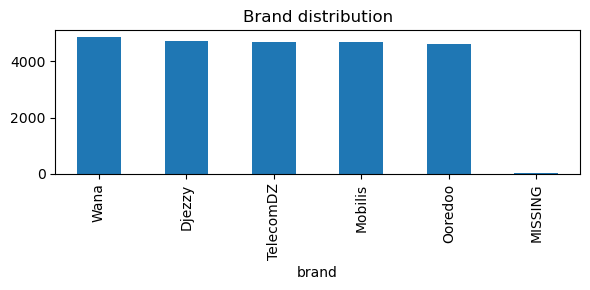

In [8]:
brand_counts = df['brand'].fillna('MISSING').value_counts()
plt.figure(figsize=(6,3))
brand_counts.plot(kind='bar')
plt.title('Brand distribution')
plt.tight_layout()

# Region

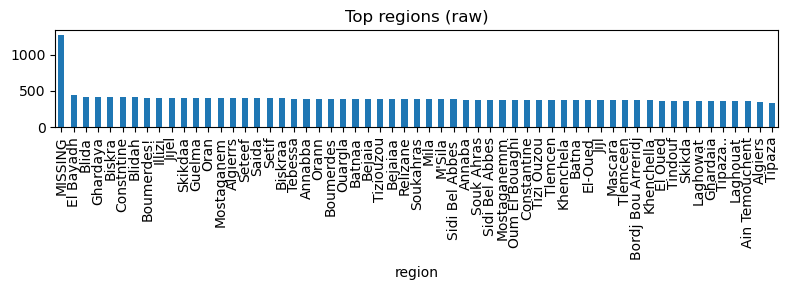

In [9]:
region_counts = df['region'].fillna('MISSING').value_counts()
plt.figure(figsize=(8,3))
region_counts.plot(kind='bar')
plt.title('Top regions (raw)')
plt.tight_layout()

# Content

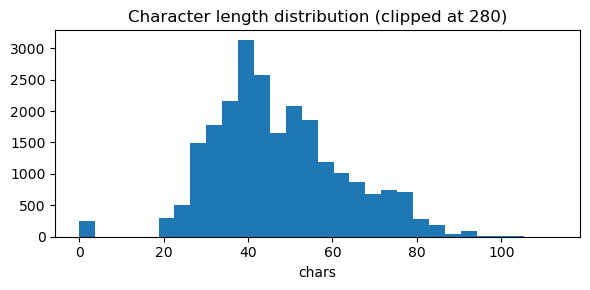

In [10]:
df['content_str'] = df['content'].fillna('').astype(str)
df['char_len'] = df['content_str'].apply(len)
plt.figure(figsize=(6,3))
plt.hist(df['char_len'].clip(upper=280), bins=30)
plt.title('Character length distribution (clipped at 280)')
plt.xlabel('chars')
plt.tight_layout()

# duplicates

In [26]:
df = df2.copy()

In [27]:
print(f"Duplicate rows: {df.duplicated().sum()}")

Duplicate rows: 572


# drop the missing content

In [28]:
df = df[df['content'].notnull() & (df['content'].str.strip() != "")]
print("Remaining rows after dropping empty content:", len(df))

Remaining rows after dropping empty content: 23332


# cleaning the content

In [29]:


def remove_emojis(text):
    """Remove emojis using emoji lib."""
    return emoji.replace_emoji(str(text), replace='')

def clean_text(text):
    text = str(text)
    text = re.sub(r"<.*?>", '', text)               # remove HTML tags
    text = re.sub(r"http\S+|www\S+", '', text)      # remove URLs
    text = remove_emojis(text)
    text = re.sub(r"[^\w\s]", '', text)             # remove punctuation
    text = re.sub(r"\s+", ' ', text).strip()        # collapse multiple spaces
    return text.lower()

# Apply cleaning
df["clean_content"] = df["content"].apply(clean_text)

# Remove duplicates based on cleaned content
df.drop_duplicates(subset=["brand", "region", "clean_content"], inplace=True)


In [30]:
df.shape

(13828, 6)

In [31]:
def detect_language(text):
    try:
        return langdetect.detect(text)
    except:
        return "unknown"

df["lang"] = df["clean_content"].apply(detect_language)
df["lang"].value_counts().head(10)


lang
en    9800
fr    1166
ar    1096
af     457
nl     302
sv     197
es     169
no     140
it      98
da      81
Name: count, dtype: int64

In [32]:
df[["clean_content" , "lang"]]

,clean_content,lang
0,why does tethering fail,en
1,working fine today thumbs up djezzy,en
2,why does tethering fail,en
3,test speed 02 mbps in ghardaya,en
4,test speed 02 mbps in eloued,en
...,...,...
23562,why am i charged for sms i never sent httpssup...,en
23566,no service since morning ooredoo,en
23570,app login fails with error code 403,en
23571,app asks for permission every open,en


In [34]:
# keep only top 3 languages for Djezzy-related analysis
top_langs = ['en', 'fr', 'ar']
df = df[df['lang'].isin(top_langs)]
df.shape

(12062, 7)

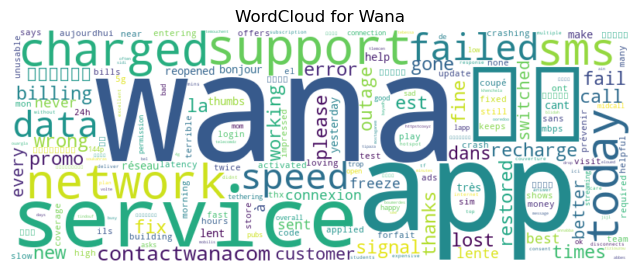

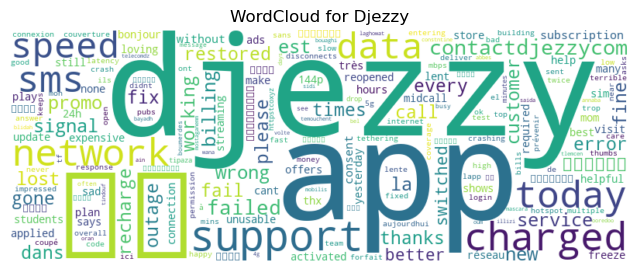

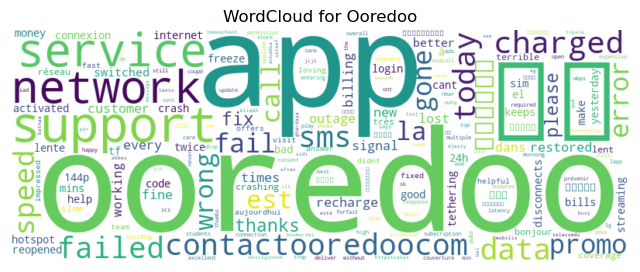

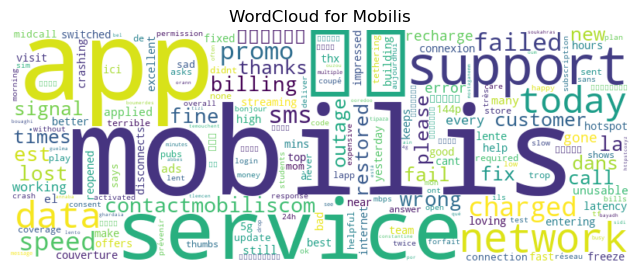

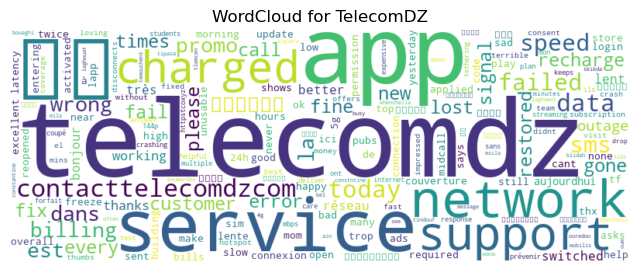

In [35]:
for brand in df["brand"].unique():
    subset = " ".join(df[df["brand"] == brand]["clean_content"].values)
    if len(subset) > 50:
        plt.figure(figsize=(8,4))
        wc = WordCloud(width=800, height=300, background_color="white", collocations=False).generate(subset)
        plt.imshow(wc, interpolation="bilinear")
        plt.axis("off")
        plt.title(f"WordCloud for {brand}")
        plt.show()


# cleaning region

In [36]:
df["region"].unique()

array(['Jijel', 'Ain Temouchent', 'Mostaganemm', 'Ghardaya', nan,
       'El Bayadh', 'Batna', 'Khenchela', 'Tipaza', 'Laghouat', 'Illizi',
       'Souk Ahras', 'Relizane', 'Oum El Bouaghi', 'Blidah', 'Tindouf',
       'Boumerdes!', 'Annabba', 'Soukahras', 'Bejaiaa', 'Laghowat',
       'El Oued', 'Setif', 'Biskraa', 'Tipaza..', 'Constantine',
       'Sidi Bel Abbes', 'Khenchella', 'Ouargla', 'Mostaganem', 'Skikda',
       'Tlemcen', 'Algiers', 'Biskra', 'Seteef', 'Tizi Ouzou',
       'Boumerdes', 'Saida', 'Ghardaia', 'Bordj Bou Arreridj', 'Batnaa',
       'Annaba', 'Skikdaa', 'Sidi Bel Abbes ', 'Mascara', 'Mila',
       'Tebessa', 'Algierrs', 'El-Oued', 'Constntine', 'Blida', 'Oran',
       'Bejaia', 'Orann', 'Tlemceen', 'Jijl', "M'Sila", 'Guelma',
       'Tiziouzou'], dtype=object)

In [37]:

region_map = {
    # perfect or near-perfect duplicates
    'Algiers': 'Alger',
    'Algierrs': 'Alger',
    'Oran': 'Oran',
    'Orann': 'Oran',
    'Blida': 'Blida',
    'Blidah': 'Blida',
    'Batna': 'Batna',
    'Batnaa': 'Batna',
    'Bejaia': 'Bejaia',
    'Bejaiaa': 'Bejaia',
    'Biskra': 'Biskra',
    'Biskraa': 'Biskra',
    'Boumerdes': 'Boumerdes',
    'Boumerdes!': 'Boumerdes',
    'Bordj Bou Arreridj': 'Bordj Bou Arreridj',
    'Chlef': 'Chlef',
    'Constantine': 'Constantine',
    'Constntine': 'Constantine',
    'Setif': 'Setif',
    'Seteef': 'Setif',
    'Tizi Ouzou': 'Tizi Ouzou',
    'Tiziouzou': 'Tizi Ouzou',
    'Jijel': 'Jijel',
    'Jijl': 'Jijel',
    "M'Sila": 'M\'Sila',
    'Mascara': 'Mascara',
    'Ghardaia': 'Ghardaia',
    'Ghardaya': 'Ghardaia',
    'Laghouat': 'Laghouat',
    'Laghowat': 'Laghouat',
    'Annaba': 'Annaba',
    'Annabba': 'Annaba',
    'Skikda': 'Skikda',
    'Skikdaa': 'Skikda',
    'Sidi Bel Abbes': 'Sidi Bel Abbes',
    'Sidi Bel Abbes ': 'Sidi Bel Abbes',
    'Saida': 'Saida',
    'Tlemcen': 'Tlemcen',
    'Tlemceen': 'Tlemcen',
    'Mila': 'Mila',
    'Souk Ahras': 'Souk Ahras',
    'Soukahras': 'Souk Ahras',
    'El Oued': 'El Oued',
    'El-Oued': 'El Oued',
    'El Bayadh': 'El Bayadh',
    'Ouargla': 'Ouargla',
    'Oum El Bouaghi': 'Oum El Bouaghi',
    'Tebessa': 'Tebessa',
    'Tipaza': 'Tipaza',
    'Tipaza..': 'Tipaza',
    'Relizane': 'Relizane',
    'Mostaganem': 'Mostaganem',
    'Mostaganemm': 'Mostaganem',
    'Illizi': 'Illizi',
    'Khenchela': 'Khenchela',
    'Khenchella': 'Khenchela',
    'Saida': 'Saida',
    'Mascara': 'Mascara',
    'Ain Temouchent': 'Ain Temouchent',
    'El Tarf': 'El Tarf'
}
df['region'] = df['region'].replace(region_map)

In [40]:
df["region"].unique()

array(['Jijel', 'Ain Temouchent', 'Mostaganem', 'Ghardaia', nan,
       'El Bayadh', 'Batna', 'Khenchela', 'Tipaza', 'Laghouat', 'Illizi',
       'Souk Ahras', 'Relizane', 'Oum El Bouaghi', 'Blida', 'Tindouf',
       'Boumerdes', 'Annaba', 'Bejaia', 'El Oued', 'Setif', 'Biskra',
       'Constantine', 'Sidi Bel Abbes', 'Ouargla', 'Skikda', 'Tlemcen',
       'Alger', 'Tizi Ouzou', 'Saida', 'Bordj Bou Arreridj', 'Mascara',
       'Mila', 'Tebessa', 'Oran', "M'Sila", 'Guelma'], dtype=object)

In [41]:
print(f"Final shape: {df.shape}")
print(df.isnull().sum())

Final shape: (12062, 7)
id                 0
date               0
brand             14
region           510
content            0
clean_content      0
lang               0
dtype: int64


In [46]:
df =df.fillna({"region": "missing" , "brand":"missing"} )

# brand inspection

In [48]:
df["brand"].unique()

array(['Wana', 'Djezzy', 'Ooredoo', 'Mobilis', 'TelecomDZ', 'missing'],
      dtype=object)

In [50]:
print(f"Final shape: {df.shape}")
print(df.isnull().sum())

Final shape: (12062, 7)
id               0
date             0
brand            0
region           0
content          0
clean_content    0
lang             0
dtype: int64


In [55]:
df.columns

Index(['id', 'date', 'brand', 'region', 'content', 'clean_content', 'lang'], dtype='object')

In [56]:
df = df.drop(columns ="content")

In [58]:
df.to_csv("cleaned.csv")